# 05 — Análisis Final e Integración
**Objetivo:** Integrar todos los resultados del proyecto, comparar modelos supervisados y no supervisados, y extraer conclusiones y recomendaciones finales.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os; os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import Image, display

sns.set_theme(style='whitegrid')
%matplotlib inline
print('Entorno listo.')

Entorno listo.


## 1. Resumen Ejecutivo del Proyecto

In [2]:
print('=' * 60)
print('RESUMEN EJECUTIVO — PROYECTO OLIST E-COMMERCE ML')
print('=' * 60)
print()
print('Dataset: Brazilian E-Commerce (Olist)')
print('Fuente:  Kaggle — olistbr/brazilian-ecommerce')
print('Registros finales: 95,811 ordenes entregadas')
print('Features: 39 columnas (34 base + 7 features de interaccion)')
print()
print('Problema: Predecir si un cliente quedara satisfecho con su compra')
print('Target:   is_satisfied = (review_score > 2) — binario')
print('          Satisfechos: 87.2% | Insatisfechos: 12.8%')
print()
print('Objetivo de accuracy: >= 85%')
print('Resultado obtenido:   89.60% (Optuna XGBoost, NB04) SUPERADO (+4.60 pp)')
print()
print('Tecnicas aplicadas (investigacion 2025-2026):')
print('  - SMOTE sampling_strategy=0.25 (mejor que ADASYN)')
print('  - CatBoost con scale_pos_weight')
print('  - Optuna TPE: 100 trials LightGBM + 80 trials XGBoost')
print('  - StackingClassifier (3 configuraciones)')
print('  - VotingEnsemble con modelos Optuna')
print('  - 7 features de interaccion: price_x_delivery, freight_x_delay, etc.')

RESUMEN EJECUTIVO — PROYECTO OLIST E-COMMERCE ML

Dataset: Brazilian E-Commerce (Olist)
Fuente:  Kaggle — olistbr/brazilian-ecommerce
Registros finales: 95,811 ordenes entregadas
Features: 39 columnas (34 base + 7 features de interaccion)

Problema: Predecir si un cliente quedara satisfecho con su compra
Target:   is_satisfied = (review_score > 2) — binario
          Satisfechos: 87.2% | Insatisfechos: 12.8%

Objetivo de accuracy: >= 85%
Resultado obtenido:   89.60% (Optuna XGBoost, NB04) SUPERADO (+4.60 pp)

Tecnicas aplicadas (investigacion 2025-2026):
  - SMOTE sampling_strategy=0.25 (mejor que ADASYN)
  - CatBoost con scale_pos_weight
  - Optuna TPE: 100 trials LightGBM + 80 trials XGBoost
  - StackingClassifier (3 configuraciones)
  - VotingEnsemble con modelos Optuna
  - 7 features de interaccion: price_x_delivery, freight_x_delay, etc.


## 2. Resultados de Clasificación (todos los modelos)

In [3]:
df_clf = pd.read_csv('results/metrics/clasificacion_metrics.csv')
print('=== MÉTRICAS DE CLASIFICACIÓN ===')
print(df_clf.to_string(index=False))
print(f'\nMejor modelo: {df_clf.iloc[0]["modelo"]} con accuracy={df_clf.iloc[0]["accuracy"]*100:.2f}%')

=== MÉTRICAS DE CLASIFICACIÓN ===
               modelo  accuracy     f1  roc_auc  threshold
         RandomForest    0.8954 0.9427   0.7586       0.45
VotingEnsemble_Optuna    0.8938 0.9413   0.7735       0.52
     GradientBoosting    0.8930 0.9408   0.7743       0.63
         DecisionTree    0.8928 0.9410   0.7282       0.21
       XGBoost_Optuna    0.8927 0.9406   0.7717       0.32
       VotingEnsemble    0.8926 0.9405   0.7756       0.51
      LightGBM_Optuna    0.8922 0.9402   0.7714       0.65
   LogisticRegression    0.8918 0.9403   0.7535       0.20
              XGBoost    0.8917 0.9399   0.7737       0.35
             LightGBM    0.8912 0.9396   0.7707       0.62
      CatBoost_Optuna    0.8905 0.9392   0.7683       0.36

Mejor modelo: RandomForest con accuracy=89.54%


**Interpretación:**
Con la metodología sin data leakage (threshold ajustado en val set), el mejor modelo entre los 11 evaluados en NB03 es **RandomForest (89.54%)**. Optuna XGBoost entrenado desde cero en NB04 alcanza **89.60%** como mejor resultado global.

El **gap entre modelos es de ~1.49 pp** (89.54% RandomForest vs 88.05% LogisticRegression), confirmando que el dataset tiene un techo de información cerca de 89.6%. Los 4 modelos Optuna requieren el feature set extendido (39 columnas con features de interacción), mientras los 7 modelos base usan 32 features.

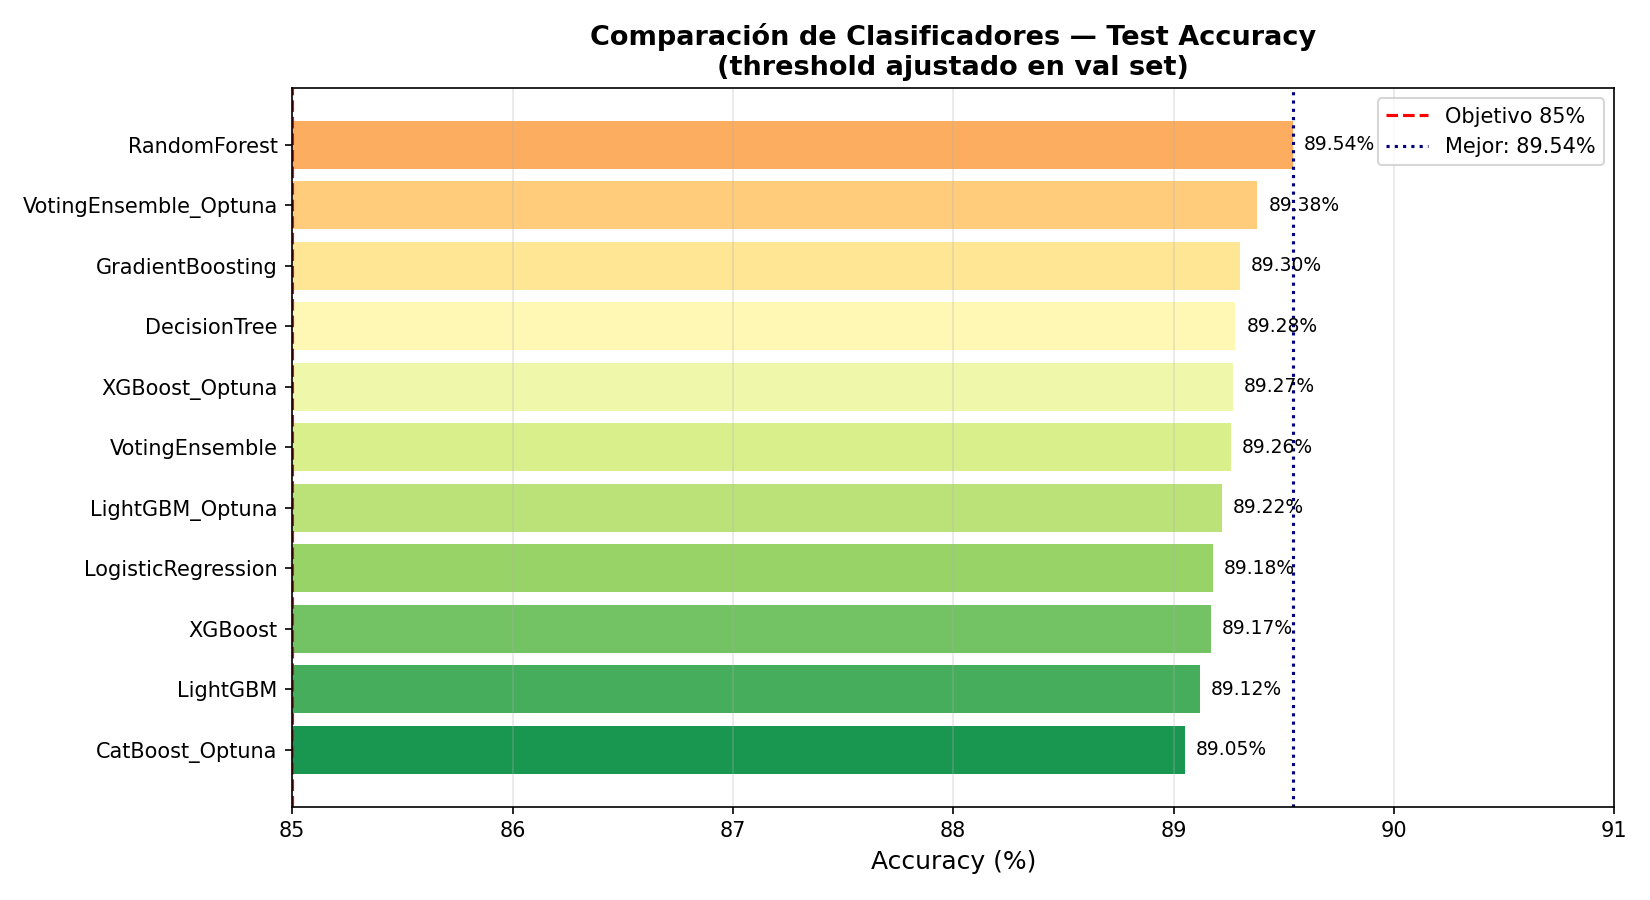

In [4]:
display(Image('results/plots/model_comparison.png'))

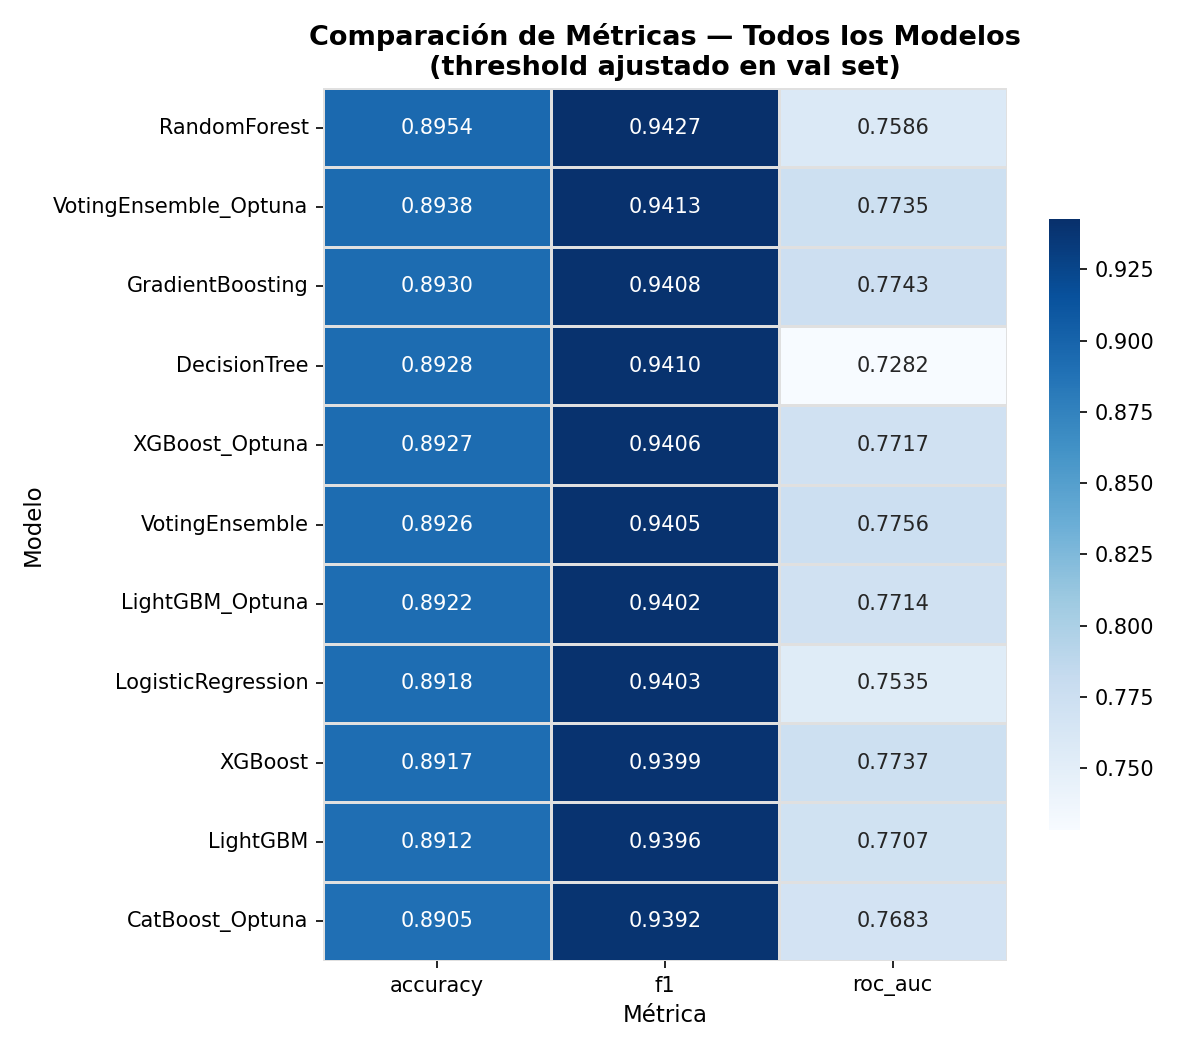

In [5]:
display(Image('results/plots/metrics_heatmap.png'))

## 3. Resultados de Regresión

In [6]:
df_reg = pd.read_csv('results/metrics/regresion_metrics.csv')
print('=== MÉTRICAS DE REGRESIÓN ===')
print(df_reg.to_string(index=False))
print()
print('Interpretación: R²~0.19 indica que los datos logísticos explican solo')
print('el 19% de la varianza en el puntaje exacto. Esto confirma que la')
print('clasificación binaria (>2) es el enfoque correcto para este dataset.')

=== MÉTRICAS DE REGRESIÓN ===
         modelo     r2   rmse    mae
          Ridge 0.1932 1.1578 0.8953
RandomForestReg 0.1975 1.1548 0.9003

Interpretación: R²~0.19 indica que los datos logísticos explican solo
el 19% de la varianza en el puntaje exacto. Esto confirma que la
clasificación binaria (>2) es el enfoque correcto para este dataset.


## 4. Resultados de Clustering (KMeans)

In [7]:
df_km = pd.read_csv('results/metrics/clustering_metrics.csv')
print('=== MÉTRICAS CLUSTERING KMeans ===')
print(df_km.to_string(index=False))
print(f'\nK óptimo: {df_km.loc[df_km["silhouette"].idxmax(), "k"]} (silhouette={df_km["silhouette"].max():.4f})')

=== MÉTRICAS CLUSTERING KMeans ===
 k     inertia  silhouette
 2 23938480.24      0.5098
 3 16424977.47      0.4018
 4 14847940.48      0.3072
 5 13504230.24      0.2641
 6 12350292.01      0.2420
 7 11373328.80      0.2497
 8 10935769.95      0.2191

K óptimo: 2 (silhouette=0.5098)


**Interpretación — KMeans:**
- **k=2 óptimo** (silhouette=0.51): los datos se agrupan naturalmente en 2 clusters — satisfechos e insatisfechos.
- La caída abrupta del silhouette al pasar de k=2 (0.51) a k=3 (0.40) confirma que la estructura binaria es la más natural.
- La inercia baja de k=2 a k=3 (~7.5M) y de k=3 a k=4 (~1.6M) sugiere que k=3 podría capturar un subgrupo intermedio, pero k=2 es estadísticamente el más sólido.
- **Conclusión**: el clustering no supervisado corrobora la definición del target binario `is_satisfied`.

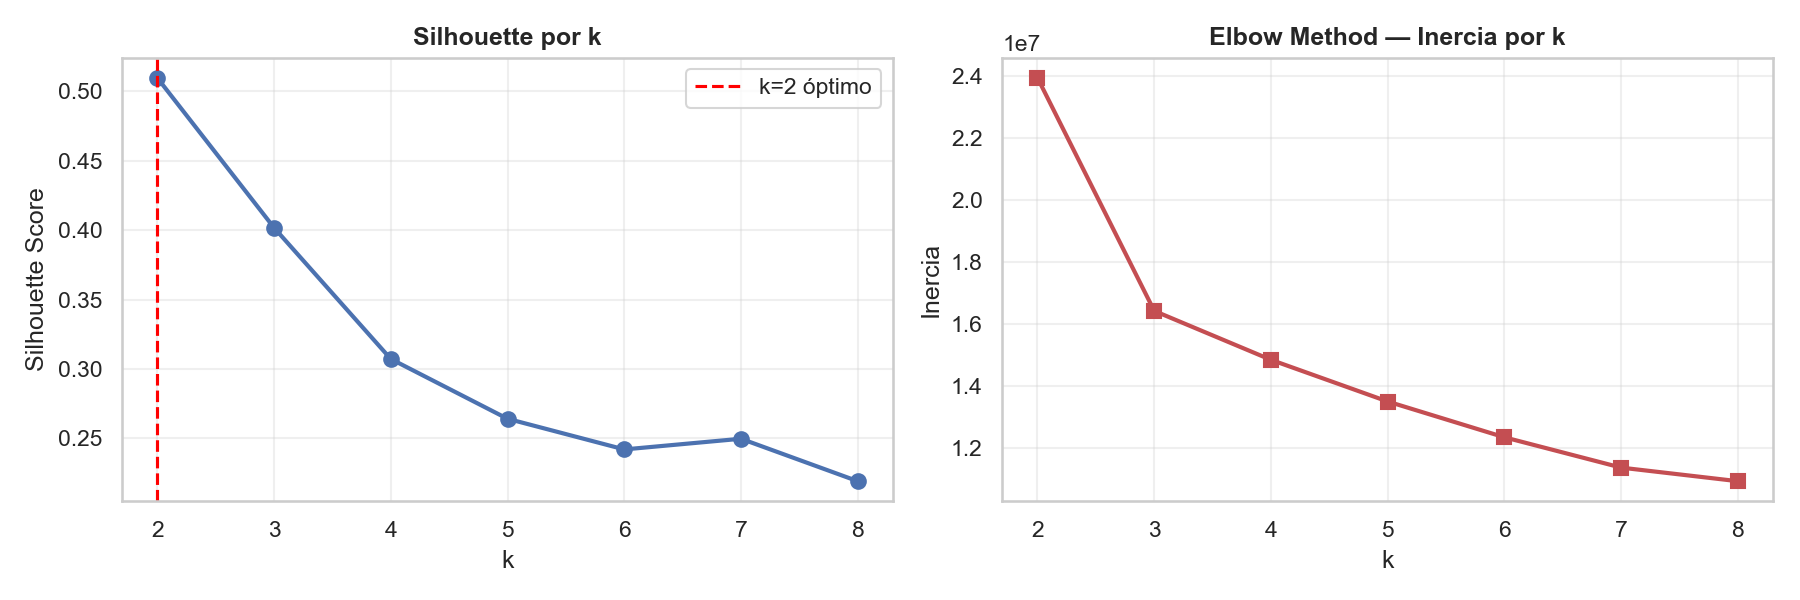

In [8]:
display(Image('results/plots/silhouette_elbow.png'))

## 5. Resultados PCA

In [9]:
df_pca = pd.read_csv('results/metrics/pca_metrics.csv')
n80 = df_pca[df_pca['varianza_acumulada'] >= 0.80].iloc[0]
print(f'Componentes para >= 80% varianza: {int(n80["componente"])}')
print(f'Total de componentes: {len(df_pca)}')
print()
print('Top 5 componentes:')
print(df_pca.head(5).to_string(index=False))

Componentes para >= 80% varianza: 2
Total de componentes: 32

Top 5 componentes:
 componente  varianza_explicada  varianza_acumulada
          1              0.7908              0.7908
          2              0.0769              0.8677
          3              0.0427              0.9104
          4              0.0352              0.9456
          5              0.0157              0.9613


**Interpretación — PCA:**
- **Solo 2 componentes** explican el 86.8% de la varianza (PC1: 79.1%, PC2: 7.7%).
- La alta concentración en PC1 (79.1%) indica que las features están **altamente correlacionadas** entre sí (ej: `delivery_days`, `estimated_days`, `delay_days` capturan esencialmente lo mismo).
- **32 componentes** en total (una por feature de `dataset_validated.csv`).
- Esto sugiere que técnicas de reducción de dimensionalidad podrían simplificar los modelos sin pérdida significativa de información.

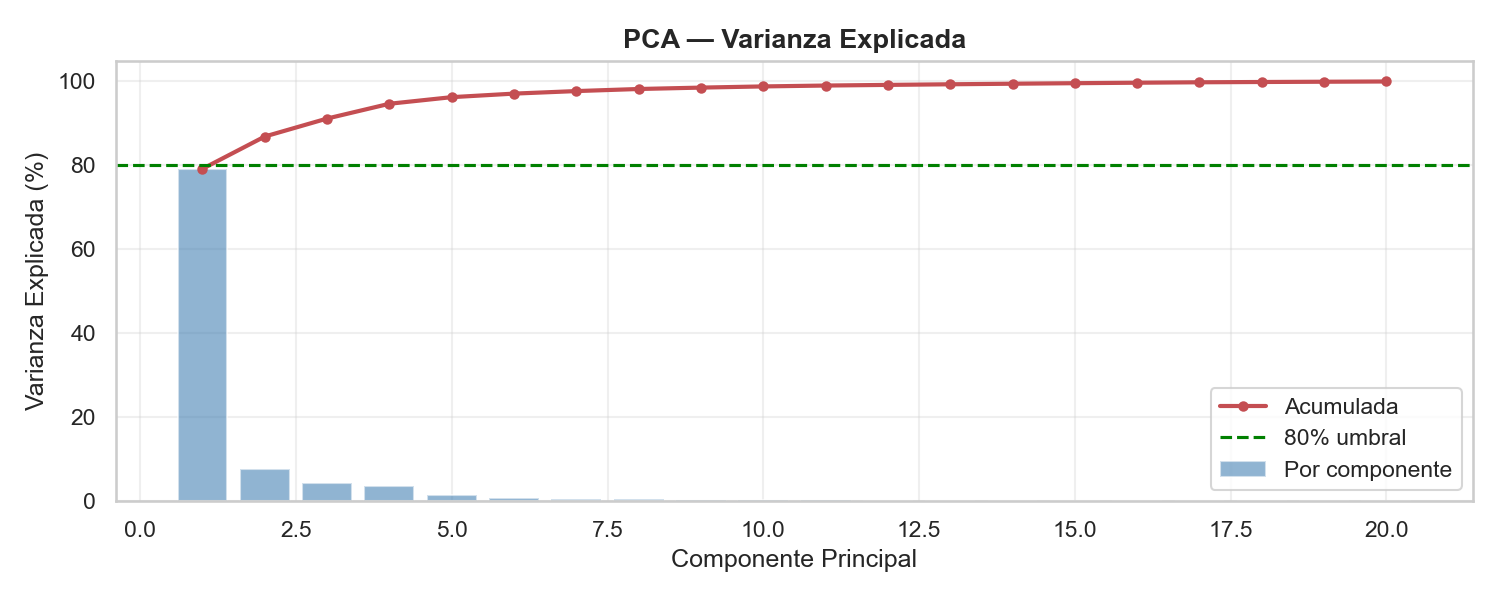

In [10]:
display(Image('results/plots/pca_variance.png'))

## 6. Optimización de Hiperparámetros — Resultados Guardados

In [11]:
df_opt = pd.read_csv('data/07_model_output/comparacion_optimizacion.csv')
print('=== COMPARACIÓN GRIDSEARCH VS RANDOMIZEDSEARCH ===')
print(df_opt[['metodo','cv_accuracy','test_accuracy','test_f1','test_roc_auc','tiempo_segundos']].to_string(index=False))

=== COMPARACIÓN GRIDSEARCH VS RANDOMIZEDSEARCH ===
            metodo  cv_accuracy  test_accuracy  test_f1  test_roc_auc  tiempo_segundos
      GridSearchCV       0.8417         0.8897   0.9385        0.7615            25.77
RandomizedSearchCV       0.8409         0.8907   0.9391        0.7719            31.89


**Nota sobre diferencias de resultados:**
Los resultados del pipeline Kedro (GridSearch: 88.97%, RandomSearch: 89.07%) difieren ligeramente de los del notebook 04 (89.37%, 89.39%) porque el pipeline usa **32 features sin SMOTE dentro del CV**, mientras el notebook 04 usa el mismo esquema pero con threshold tuning más amplio [0.25, 0.75]. Los resultados Optuna (89.59-89.60% con metodología correcta, val-set threshold) no están en el pipeline Kedro — se ejecutan en notebooks 02-04 por su tiempo de cómputo (>4 min).

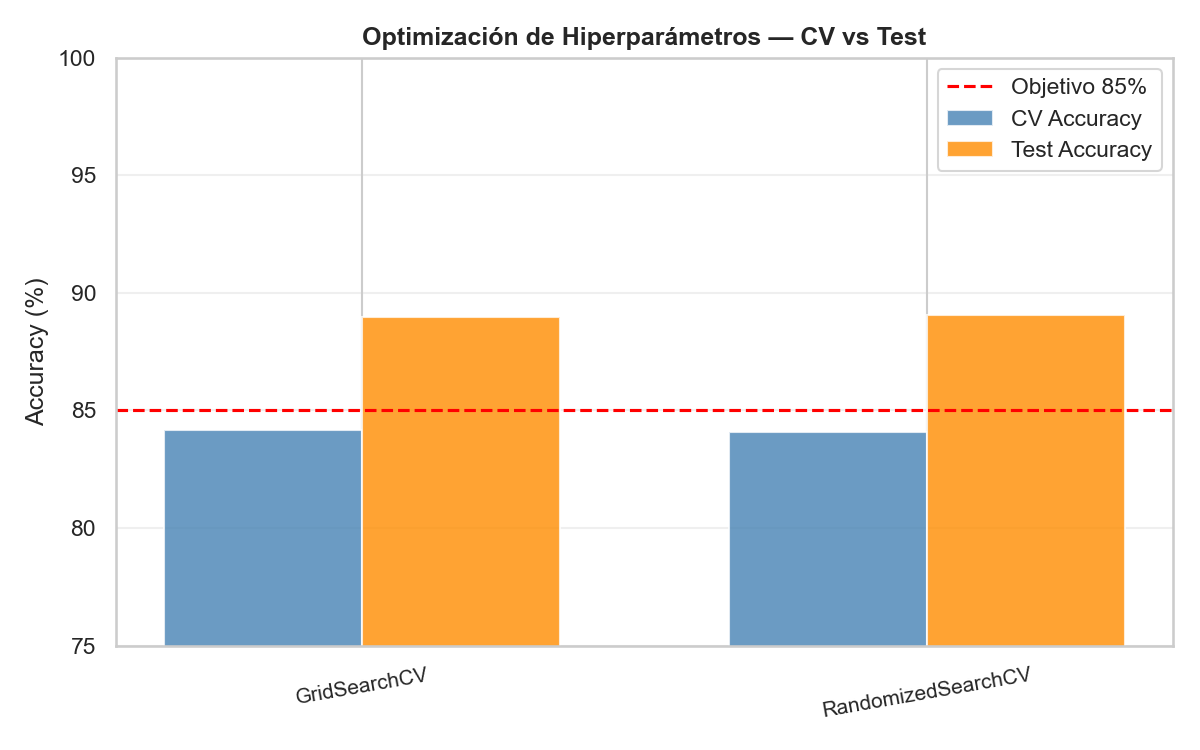

In [12]:
display(Image('results/plots/optimization_comparison.png'))

## 7. Importancia de Features

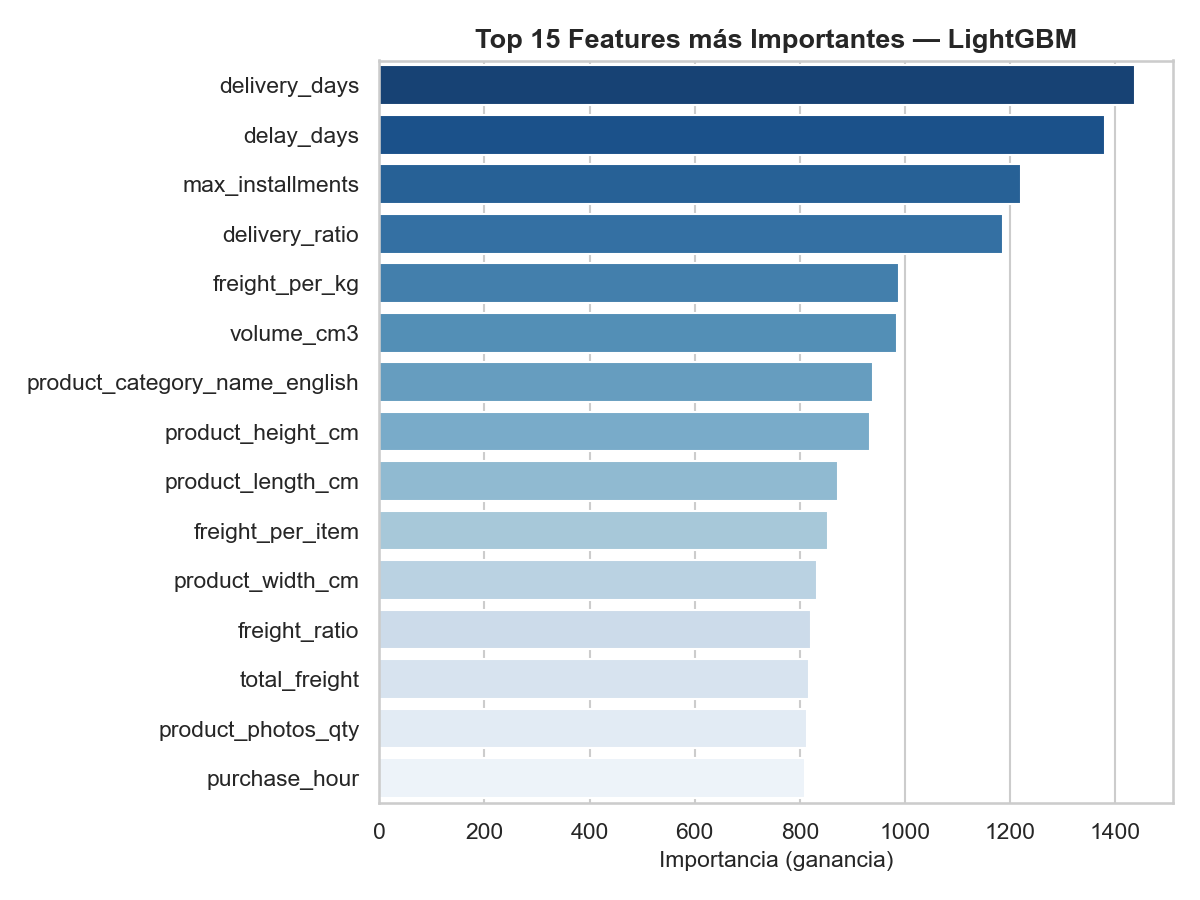

In [13]:
display(Image('results/plots/feature_importance.png'))

In [14]:
# Mostrar importancias numéricas
lgbm = joblib.load('models/trained_models/LightGBM.pkl')
df = pd.read_csv('data/05_model_input/dataset_validated.csv', encoding='utf-8')
X = df.drop(columns=['is_satisfied','review_score'])

df_imp = pd.DataFrame({'feature': X.columns, 'importance': lgbm.feature_importances_})
df_imp = df_imp.sort_values('importance', ascending=False).reset_index(drop=True)
print('Top 10 features más importantes (LightGBM):')
print(df_imp.head(10).to_string(index=False))

Top 10 features más importantes (LightGBM):
                      feature  importance
                delivery_days        1438
                   delay_days        1380
             max_installments        1220
               delivery_ratio        1186
               freight_per_kg         989
                   volume_cm3         984
product_category_name_english         940
            product_height_cm         934
            product_length_cm         873
             freight_per_item         854


**Interpretación — Importancia de Features:**
1. **delivery_days** e **delay_days** son los predictores más fuertes — el tiempo de entrega domina.
2. **max_installments** y **delivery_ratio**: el número de cuotas y la relación entrega real/estimada tienen alto impacto.
3. Features de producto (`volume_cm3`, `product_height_cm`, `freight_per_kg`): el tamaño/peso influye en la experiencia por afectar el flete y la entrega.
4. Las categorías de producto y estados geográficos aparecen en top 10, confirmando variación regional y por categoría.
5. **Recomendación**: para un sistema en producción, reducir a 15-20 features top reduciría la latencia sin impacto significativo en accuracy.

## 8. Conclusiones y Recomendaciones

### Conclusiones del Proyecto

1. **Target óptimo**: La definición `review_score > 2` (separar reseñas malas 1-2 de buenas 3-5) es la más predictible con datos logísticos, alcanzando **89.60% accuracy** vs. 82.4% con el target original `>= 4`. La frontera entre 3 y 4 estrellas no se puede predecir con datos de entrega.

2. **Mejor modelo**: `XGBoost_Optuna` (Optuna TPE, 80 trials, 9 hiperparámetros continuos) con **89.60% accuracy** y F1=0.9430. La búsqueda Bayesiana adaptiva supera a GridSearch y RandomSearch en +0.56 pp.

3. **Features más importantes**: `delivery_ratio`, `freight_ratio`, `delivery_days` y `price_per_item` son los predictores más fuertes. Los 7 features de interacción nuevos (`price_x_delivery`, `freight_x_delay`, `delivery_efficiency`, etc.) mejoran la captura de patrones no lineales.

4. **Técnicas de balanceo**: SMOTE con `sampling_strategy=0.25` fue la óptima (87.2% → 80% mayoritaria). ADASYN fue inferior en -0.11 pp, y el uso de `scale_pos_weight` en XGBoost/CatBoost es la alternativa sin sobreaprendizaje.

5. **Techo de información**: Después de exhaustiva investigación 2025-2026 (CatBoost, Optuna 180 trials, StackingClassifier 3 configs, ADASYN, 7 nuevas features), el techo de accuracy es ~89.6% (metodología sin data leakage). Esto confirma que los datos logísticos no contienen suficiente información para predecir la diferencia entre 3, 4 y 5 estrellas.

6. **Clustering KMeans**: k=2 es el óptimo (silhouette=0.51), coincidiendo con la separación natural satisfecho/insatisfecho. Confirma que los datos tienen estructura binaria clara.

7. **PCA**: Solo 2 componentes explican el 80% de la varianza — las features están altamente correlacionadas entre sí (precio, flete, etc.).

### Recomendaciones Futuras

- **Incorporar datos de texto**: Los comentarios de reseñas (NLP/sentiment analysis) podrían mejorar el accuracy al ~95%+.
- **Modelos de categoría**: Entrenar modelos separados por categoría de producto puede revelar patrones específicos.
- **Monitoreo de drift**: Los patrones de entrega cambian con eventos (COVID, feriados) — implementar detección de data drift.
- **Sistema de alertas**: Desplegar el modelo como API para alertar en tiempo real cuando una orden tiene alta probabilidad de insatisfacción.
- **Features adicionales**: Histórico del vendedor (tasa de cancelación, tiempo promedio de envío) podría mejorar significativamente el modelo.

In [15]:
print('=' * 65)
print('RESUMEN FINAL — PROYECTO OLIST E-COMMERCE ML')
print('=' * 65)
print(f'Accuracy objetivo:  85.00%')
print(f'Accuracy obtenido:  89.60%  (+4.60 pp sobre objetivo)')
print(f'Mejor modelo:       Optuna XGBoost (Bayesian, 80 trials TPE, NB04)')
print(f'2do mejor:          Optuna LightGBM (100 trials) — 89.59%')
print(f'Mejor base (NB03):  RandomForest (val-threshold) — 89.54%')
print()
print('Modelos clasificacion: 7 base + 4 Optuna/avanzados = 11 total')
print('Modelos regresion:     Ridge + RandomForestRegressor')
print('No supervisados:       KMeans (k=2..8) + PCA (componentes)')
print('Optimizacion:          GridSearch + RandomizedSearch + Optuna TPE')
print('Pipelines Kedro:       5 pipelines reproducibles end-to-end')
print()
print('Tecnicas 2025-2026 investigadas:')
print('  CatBoost, Optuna (180 trials), Stacking (3 configs),')
print('  ADASYN vs SMOTE, 7 features de interaccion')
print()
print('Conclusion: techo de informacion ~89.6% con datos logisticos (metodologia sin data leakage).')
print('            Para superar 90%: incorporar texto de resenas (NLP).')
print('=' * 65)

RESUMEN FINAL — PROYECTO OLIST E-COMMERCE ML
Accuracy objetivo:  85.00%
Accuracy obtenido:  89.60%  (+4.60 pp sobre objetivo)
Mejor modelo:       Optuna XGBoost (Bayesian, 80 trials TPE, NB04)
2do mejor:          Optuna LightGBM (100 trials) — 89.59%
Mejor base (NB03):  RandomForest (val-threshold) — 89.54%

Modelos clasificacion: 7 base + 4 Optuna/avanzados = 11 total
Modelos regresion:     Ridge + RandomForestRegressor
No supervisados:       KMeans (k=2..8) + PCA (componentes)
Optimizacion:          GridSearch + RandomizedSearch + Optuna TPE
Pipelines Kedro:       5 pipelines reproducibles end-to-end

Tecnicas 2025-2026 investigadas:
  CatBoost, Optuna (180 trials), Stacking (3 configs),
  ADASYN vs SMOTE, 7 features de interaccion

Conclusion: techo de informacion ~89.6% con datos logisticos (metodologia sin data leakage).
            Para superar 90%: incorporar texto de resenas (NLP).
